# Note that this project takes place in R

![A soccer pitch for an international match.](soccer-pitch.jpg)

You're working as a sports journalist at a major online sports media company, specializing in soccer analysis and reporting. You've been watching both men's and women's international soccer matches for a number of years, and your gut instinct tells you that more goals are scored in women's international football matches than men's. This would make an interesting investigative article that your subscribers are bound to love, but you'll need to perform a valid statistical hypothesis test to be sure!

While scoping this project, you acknowledge that the sport has changed a lot over the years, and performances likely vary a lot depending on the tournament, so you decide to limit the data used in the analysis to only official `FIFA World Cup` matches (not including qualifiers) after `2002-01-01`.

You create two datasets containing the results of every official men's and women's international football match since the 19th century, which you scraped from a reliable online source. This data is stored in two CSV files: `women_results.csv` and `men_results.csv`.

The question you are trying to determine the answer to is:

> Are more goals scored in women's international soccer matches than men's?

You assume a **10% significance level**, and use the following null and alternative hypotheses:

$H_0$ : The mean number of goals scored in women's international soccer matches is the same as men's.

$H_A$ : The mean number of goals scored in women's international soccer matches is greater than men's.

In [61]:
# Import necessary libraries
library(tidyverse)
library(ggplot2)


In [62]:
#load data
orig_mens_data = read_csv("men_results.csv")
orig_womens_data = read_csv("women_results.csv")
#investigate the data
glimpse(orig_mens_data)
glimpse(orig_womens_data)

New names:
• `` -> `...1`
Rows: 44353 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (3): home_team, away_team, tournament
dbl  (3): ...1, home_score, away_score
date (1): date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
New names:
• `` -> `...1`
Rows: 4884 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (3): home_team, away_team, tournament
dbl  (3): ...1, home_score, away_score
date (1): date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 44,353
Columns: 7
$ ...1       <dbl> 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 1…
$ date       <date> 1872-11-30, 1873-03-08, 1874-03-07, 1875-03-06, 1876-03-04…
$ home_team  <chr> "Scotland", "England", "Scotland", "England", "Scotland", "…
$ away_team  <chr> "England", "Scotland", "England", "Scotland", "England", "W…
$ home_score <dbl> 0, 4, 2, 2, 3, 4, 1, 0, 7, 9, 2, 5, 0, 5, 2, 5, 0, 1, 1, 0,…
$ away_score <dbl> 0, 2, 1, 2, 0, 0, 3, 2, 2, 0, 1, 4, 3, 4, 3, 1, 1, 6, 5, 13…
$ tournament <chr> "Friendly", "Friendly", "Friendly", "Friendly", "Friendly",…
Rows: 4,884
Columns: 7
$ ...1       <dbl> 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 1…
$ date       <date> 1969-11-01, 1969-11-01, 1969-11-02, 1969-11-02, 1975-08-25…
$ home_team  <chr> "Italy", "Denmark", "England", "Italy", "Thailand", "Hong K…
$ away_team  <chr> "France", "England", "France", "Denmark", "Australia", "New…
$ home_score <dbl> 1, 4, 2, 3, 3, 0, 3, 3, 3, 0, 3, 3, 5, 3, 5, 2, 1, 5, 

The men's data has 44,353 rows. The women's data has 4,884 rows.

In [63]:
#investigate the data cont.
head(orig_mens_data)
head(orig_womens_data)

...1,date,home_team,away_team,home_score,away_score,tournament
<dbl>,<date>,<chr>,<chr>,<dbl>,<dbl>,<chr>
0,1872-11-30,Scotland,England,0,0,Friendly
1,1873-03-08,England,Scotland,4,2,Friendly
2,1874-03-07,Scotland,England,2,1,Friendly
3,1875-03-06,England,Scotland,2,2,Friendly
4,1876-03-04,Scotland,England,3,0,Friendly
5,1876-03-25,Scotland,Wales,4,0,Friendly


...1,date,home_team,away_team,home_score,away_score,tournament
<dbl>,<date>,<chr>,<chr>,<dbl>,<dbl>,<chr>
0,1969-11-01,Italy,France,1,0,Euro
1,1969-11-01,Denmark,England,4,3,Euro
2,1969-11-02,England,France,2,0,Euro
3,1969-11-02,Italy,Denmark,3,1,Euro
4,1975-08-25,Thailand,Australia,3,2,AFC Championship
5,1975-08-25,Hong Kong,New Zealand,0,2,AFC Championship


Perform an appropriate hypothesis test to determine the p-value, and decide whether to reject the null hypothesis that *the mean number of goals scored in women's international soccer matches is the same as men's*. Use a **10% significance level**.

Use Official `FIFA World Cup` matches after `2002-01-01`, assuming each match is fully independent and team form is ignored.
- Store the p-value and the test result in a data frame called `result_df`, with `p_val` as the p-value and `result` as either the string `"fail to reject"` or `"reject"`, based on the test outcome.

In [64]:
#Firstly, filter the datasets as specified
filt_mens <- orig_mens_data %>%
    filter(tournament == "FIFA World Cup" & date > "2002-01-01")
    #384 rows
filt_womens <- orig_womens_data %>%
    filter(tournament == "FIFA World Cup" & date > "2002-01-01")
    #200 rows
#head(filt_womens)

#Need to create a new column indicating the total # goals scored in a match. This is the test value variable.
filt_mens <- filt_mens %>%
    mutate(num_goals = home_score + away_score)
filt_womens <- filt_womens %>%
    mutate(num_goals = home_score + away_score)
head(filt_mens)

...1,date,home_team,away_team,home_score,away_score,tournament,num_goals
<dbl>,<date>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<dbl>
25164,2002-05-31,France,Senegal,0,1,FIFA World Cup,1
25165,2002-06-01,Germany,Saudi Arabia,8,0,FIFA World Cup,8
25166,2002-06-01,Republic of Ireland,Cameroon,1,1,FIFA World Cup,2
25167,2002-06-01,Uruguay,Denmark,1,2,FIFA World Cup,3
25168,2002-06-02,Argentina,Nigeria,1,0,FIFA World Cup,1
25169,2002-06-02,England,Sweden,1,1,FIFA World Cup,2


In [65]:
#Calculate some sample statistics for the 2 datasets

#AVERAGE:
num_goals_mens_avg <- mean(filt_mens$num_goals)
    #~ 2.513
num_goals_womens_avg <- mean(filt_womens$num_goals)
    # 2.98

#STANDARD DEVIATION:
num_goals_mens_sd <- sd(filt_mens$num_goals)
    #~ 1.653
num_goals_womens_sd <- sd(filt_womens$num_goals)
    #~ 2.022

#NUMBER of OBSERVATIONS:
num_goals_mens_matches <- nrow(filt_mens)
    #384
num_goals_womens_matches <- nrow(filt_womens)
    #200

Need to determine the most appropriate hypothesis test. The two datasets are independent of each other; they're unpaired. The two datasets serve as two samples; a two-sample problem. As such, a two-sample unpaired test can be used. Based on my own knowledge, can use a two-sample t-test (parametric) or a Wilcoxon-Mann-Whitney (WMW) test (non-parametric).

Can investigate the distribution of the data by creating histograms of the test value--the number of goals scored in a match. If it is normal (bell-shaped), use the parametric two-sample t-test. If it is not normal, use the non-parametric WMW test.

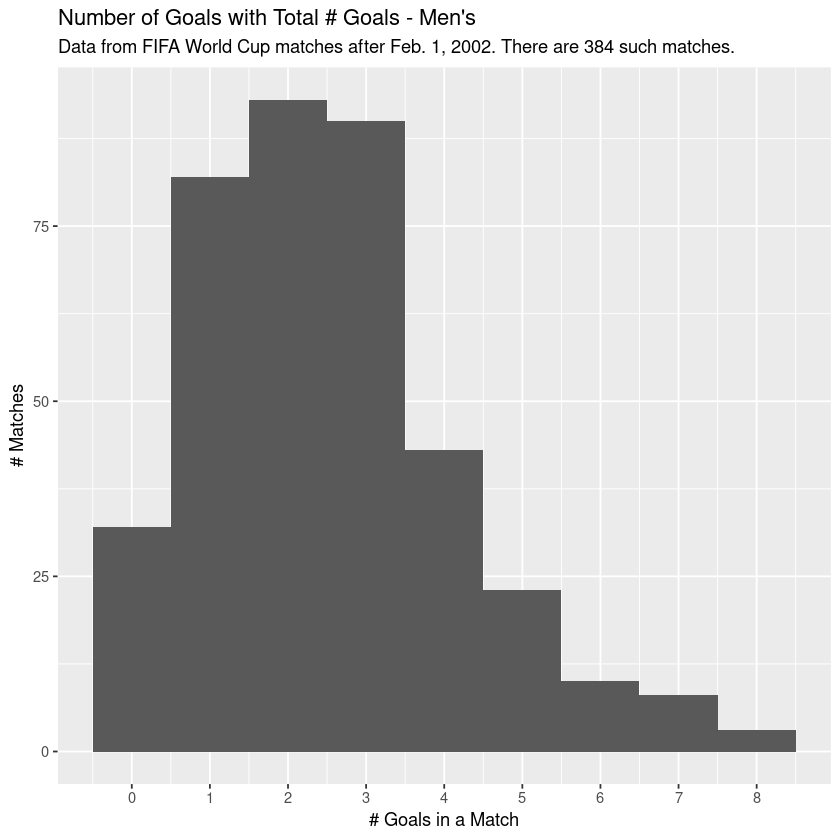

In [66]:
#Create distributions of the test variable for the two datasets. Use histograms with binwidth=1.
    #using range(), the total # goals in the filtered data ranges between: 0-8 (men's), 0-13 (women's)
#MEN's
M_goals <- ggplot(filt_mens, aes(x=num_goals)) + 
    geom_histogram(binwidth=1) + scale_x_continuous(breaks = 0:8, labels = c(0:8)) +
    labs(title="Number of Goals with Total # Goals - Men's", 
         subtitle="Data from FIFA World Cup matches after Feb. 1, 2002. There are 384 such matches.", 
         x="# Goals in a Match", y="# Matches") +
    theme(plot.title=element_text(size=11), plot.subtitle=element_text(size=9),
        axis.title.x=element_text(size=10), axis.title.y=element_text(size=10))
M_goals

This histogram above shows that the data for the number of goals scored per match in men's games is not normally distributed; it is right-skewed. As such, a non-parametric test would be more appropriate for this data.

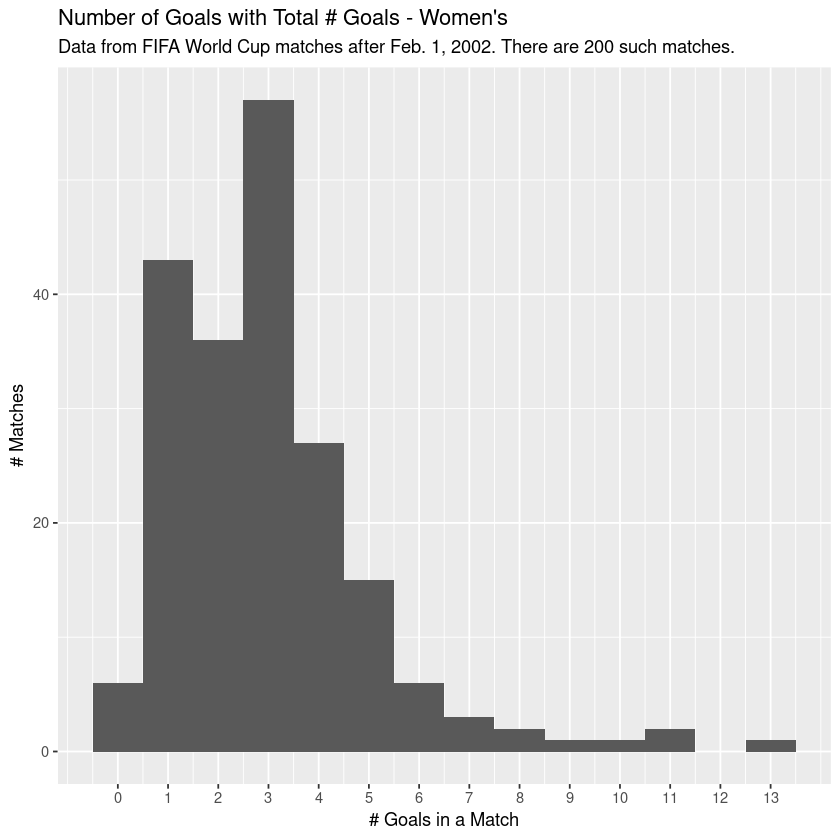

In [67]:
#WOMEN's
W_goals <- ggplot(filt_womens, aes(x=num_goals)) + 
    geom_histogram(binwidth=1) + scale_x_continuous(breaks = 0:13, labels = c(0:13)) +
    labs(title="Number of Goals with Total # Goals - Women's", 
         subtitle="Data from FIFA World Cup matches after Feb. 1, 2002. There are 200 such matches.", 
         x="# Goals in a Match", y="# Matches") +
    theme(plot.title=element_text(size=11), plot.subtitle=element_text(size=9),
        axis.title.x=element_text(size=10), axis.title.y=element_text(size=10))
W_goals

This histogram above shows that the data for the number of goals scored per match in women's games is not normally distributed; it is right-skewed. As such, a non-parametric test would be more appropriate for this data.

Since the distributions of the test statistic for both samples of data is not normal, a non-parametric test would be more appropriate. Therefore, the Wilcoxon-Mann-Whitney test is the most appropriate. Can use the wilcox.test() function to calculate the p-value, compare it to the significance level (alpha) of 10%, & determine whether or not to reject the null hypothesis.

Recall the alternative hypothesis:
>The mean number of goals scored in women's international soccer matches is *greater* than men's.

As such, can specify:
- x as the women's data,
- y as the men's data,
- alternative as "greater",
- the data is unpaired; paired=FALSE.

In [68]:
#perform the WMW hypothesis test
WMW_test <- wilcox.test(x=filt_womens$num_goals, y=filt_mens$num_goals, alternative="greater", paired=FALSE)
print(WMW_test)

#Compare the p-value of WMW_test to the significance level (alpha)
alpha <- 0.10
#print(WMW_test$p.value <= alpha)
print(ifelse(WMW_test$p.value <= alpha, "The result is significant. Can reject the null hypothesis.", 
             "The result is not significant. Fail to reject the null hypothesis."))


	Wilcoxon rank sum test with continuity correction

data:  filt_womens$num_goals and filt_mens$num_goals
W = 43273, p-value = 0.005107
alternative hypothesis: true location shift is greater than 0

[1] "The result is significant. Can reject the null hypothesis."


In [69]:
#Assign the specified variables
result_df <- data.frame(tribble(~p_val, ~result, 
                                WMW_test$p.value, ifelse(WMW_test$p.value <= alpha, "reject", "fail to reject")))
print(result_df)

       p_val result
1 0.00510661 reject
